In [ ]:
!pip install qiskit --quiet
!pip install pylatexenc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install qiskit-aer --quiet # Install the missing module
from qiskit import *
from qiskit.visualization import plot_histogram
from google.colab import widgets
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual, Button, Layout
import ipywidgets
import pandas as pd
import math
import numpy as np
import random
from IPython.display import clear_output
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.8 MB/s eta 0:00:00


The code for the game comprises the two classes below. Edit at your peril. But also, edit if you want to change the rules of the game!

In [ ]:
class Board:
    def __init__(self): # Initialization of the Game Board
        self.qc = QuantumCircuit(9, 9) # create a circuit with 9 qubits
        self.function = ''
        self.target = -1
        self.tab = []
        self.winsX = 0
        self.winsO = 0

        # Initialize the board with empty cells
        for idx in range(0, 9):
            self.tab.append({'default':str(idx), 'player':' '})
            self.qc.reset(idx)
            self.qc.h(idx)
        self.qc.barrier()

    def make_move(self, cell):
        # Make a move based on the selected function
        if self.function == 'Not':  # X gate (NOT operation)
            self.qc.x(cell)
            self.tab[int(cell)]['player'] += 'N - '
        elif self.function == 'O': # Rotation Gate (RY) rotation toward |0>
            self.qc.ry(math.pi/2, cell)
            self.tab[int(cell)]['player'] += "O - "
        elif self.function == 'X': # Rotation Gate (RY) rotation toward |1>
            self.qc.ry(-math.pi/2, cell)
            self.tab[int(cell)]['player'] += "X - "
        elif self.function == 'SWAP' and self.target != cell: # SWAP Gate
            if self.target == cell:
                self.target = -1
            else:
                # add a swap gate
                self.qc.swap(int(cell), int(self.target))
                self.tab[int(cell)]['player'] += "S - "
                self.tab[int(self.target)]['player'] += "S - "

    def results(self):
        # Display the results of the quantum circuit.
        display(self.qc.draw('mpl'))
        self.qc = QuantumCircuit(9, 9)

    def display(self):
        # Display the current state of the quantum circuit.
        display(self.qc.draw('mpl'))

    def measure(self):
        # Measure the quantum circuit and update the board based on the measurement results.
        self.qc.barrier()
        for i in range(0,9):
            self.qc.measure(i, i)

        simulator = AerSimulator()  # Initialize the AerSimulator
        job = simulator.run(self.qc, shots=2, memory=True) # Run the simulation with 1 shot and enable memory
        counts = job.result().get_counts()  # Get the result counts
        output = list(counts.keys())[0] # Extract the measurement result
        print(output)

        #output = job.result().get_memory()[0]

        # Update the board based on the measurement output
        for i in range(0,9):
            if output[9-1-i] == '0':
                self.tab[i]['player'] = 'X' # Player X wins
            else:
                self.tab[i]['player'] = 'O' # Player O wins

        self.winsX = self.countWinners('X') # Count X wins
        self.winsO = self.countWinners('O') # Count O wins

    def countWinners(self, player): # Count the number of wins for the specified player.
        # Define winning combinations (triplets)
        winners = [(0, 1, 2), # Row 1
                   (3, 4, 5), # Row 2
                   (6, 7, 8), # Row 3
                   (0, 3, 6), # Column 1
                   (1, 4, 7), # Column 2
                   (2, 5, 8), # Column 3
                   (0, 4, 8), # Diagonal \
                   (2, 4, 6)] # Diagonal /
        wins = 0
        for i in range(len(winners)):
            won = True
            for j in range(len(winners[0])):
                if not self.tab[winners[i][j]]['player'] == player:
                    won = False
            if won:
                wins = wins + 1
        return wins

    def new(self):
        # Reset the board for a new game.
        self.tab.clear()
        for idx in range(0,9):
           self.tab.append({'default':str(idx), 'player':''})
           self.qc.reset(idx)
           self.qc.h(idx)
        self.qc.barrier()


In [ ]:
class Game:
    def __init__(self): # Initialize the Game
        self.selecting = False
        self.board = Board()
        self.boardbutton_list = []
        for i in range(0,9):
            button = Button(description=str(i))
            button.on_click(self.handle_game)
            self.boardbutton_list.append(button)

        self.funcbutton_list = []
        self.newButton('Measure') # create measure button
        self.newButton('Not') # create Not button
        self.newButton('O') # create O button
        self.newButton('X') # create X button
        self.newButton('SWAP') # create SWAP button
        self.printmenu() # print the Button Menu
        self.printBoard() # print the Board

    def newButton(self, name):
        # Create a new function button.
        function = Button(description=name, layout=Layout(width='86px', height='30px')) # Button Layout settings
        function.on_click(self.handle_game)
        self.funcbutton_list.append(function)

    def handle_game(self, b):
        # Handle game events based on button clicks.
        try:
            if b.description == 'Measure':
                clear_output()
                self.replay() # replay
                self.board.measure() # Measure the quantum circuit
                self.scoreboard()    # Update the scoreboard
                self.printBoard()    # Display the board
                self.board.results() # Show the results

            if b.description == 'Replay':
                clear_output()
                self.board.new() # Reset the board for a new game
                self.printmenu()
                self.printBoard()

            if int(b.description) >= 0:
                if self.selecting:
                    self.board.target = int(b.description) # Set the target for SWAP
                else:
                    clear_output()
                    self.printmenu()
                    self.board.make_move(int(b.description)) # Make a player move
                    self.printBoard()
                    self.board.display()
            self.selecting = False
        except ValueError:
            self.board.function = b.description # Set the selected function
            self.selecting = False
            if self.board.function == 'SWAP':
                self.selecting = True     # Allow target selection for SWAP

    def printmenu(self): # Display the function menu for the game.
        grid = widgets.Grid(1, 5)
        for (row, col) in grid:
            display(self.funcbutton_list[col])

    def scoreboard(self): # Display the current score of the game.
        print("X wins: " + str(self.board.winsX) + "    O wins: " + str(self.board.winsO))

    def replay(self): # Provide a button to replay the game.
        rep = Button(description="Replay")
        rep.on_click(self.handle_game)
        display(rep)

    def printBoard(self): # Print the current state of the board.
        grid = widgets.Grid(1, int(np.sqrt(9)), header_row=True, header_column=True)
        for row in range(int(np.sqrt(9))):
              for (useless, col) in grid:
                  print("\n"+self.board.tab[col + row * int(np.sqrt(9))]['player']+"\n")
                  display(self.boardbutton_list[col + row * int(np.sqrt(9))])

In this iteration, we'll play the game on the qiskit simulator.

# The game!

To make a move, click one of the 5 options above the board and then click the location where you want to make that move. To play "SWAP," you need to click two board locations.

Each move adds a gate to the game circuit. They do the following:


*   **Measure** ends the round and execute the game circuit on the quantum device. The win conditions will be counted and displayed.
*   **Not** flips an "owned" tile to the other player. If the tile is not currently owned, this does nothing.
*   **O** turns the intial tile toward a tile owned by "O."
*   **X** turns the intial tile toward a tile owned by "X."
*   **SWAP** swaps the location of two tiles.

As you play, you will see the game circuit and the board. The board shows the sequence of moves, but is not 100% accurate. The game circuit is true state of the game.

In [ ]:
game = Game()

,,,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Button(description='Measure', layout=Layout(height='30px', width='86px'), style=ButtonStyle())

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Button(description='8', style=ButtonStyle())

<IPython.core.display.Javascript object>

In [ ]:
pip show pylatexenc

Name: pylatexenc
Version: 2.10
Summary: Simple LaTeX parser providing latex-to-unicode and unicode-to-latex conversion
Home-page: https://github.com/phfaist/pylatexenc
Author: Philippe Faist
Author-email: philippe.faist@bluewin.ch
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: 
Required-by: 


Button(description='Replay', style=ButtonStyle())

011100010
X wins: 1    O wins: 0


,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


X



Button(description='8', style=ButtonStyle())

<IPython.core.display.Javascript object>

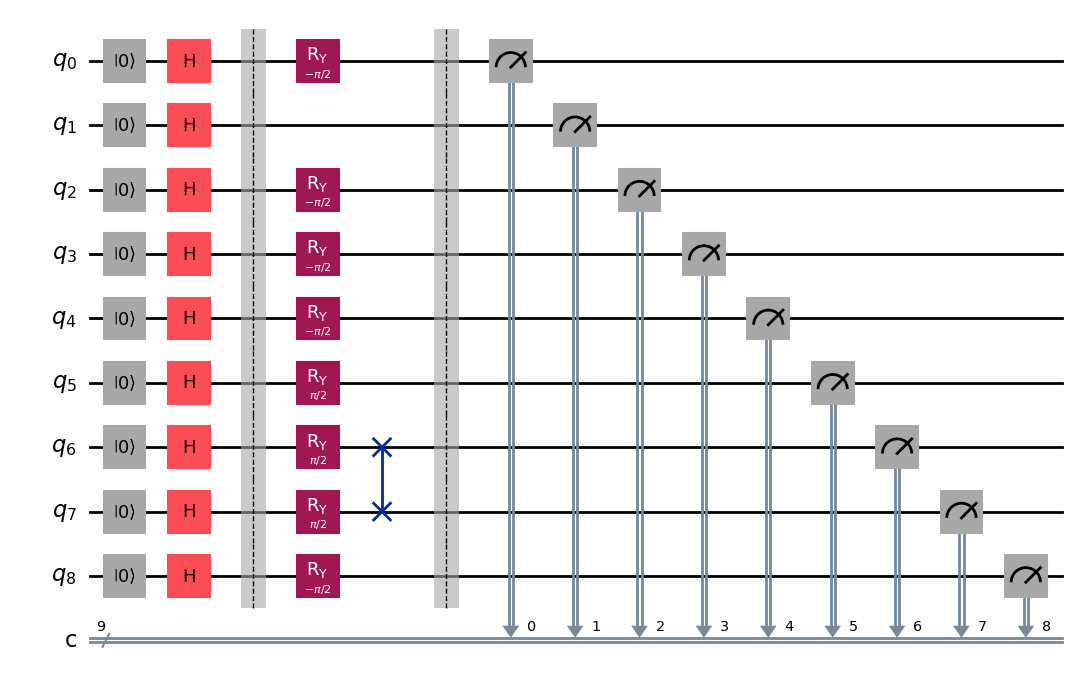

In [ ]:
# X wins
game1 = Game()

Button(description='Replay', style=ButtonStyle())

110011101
X wins: 0    O wins: 1


,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


O



Button(description='8', style=ButtonStyle())

<IPython.core.display.Javascript object>

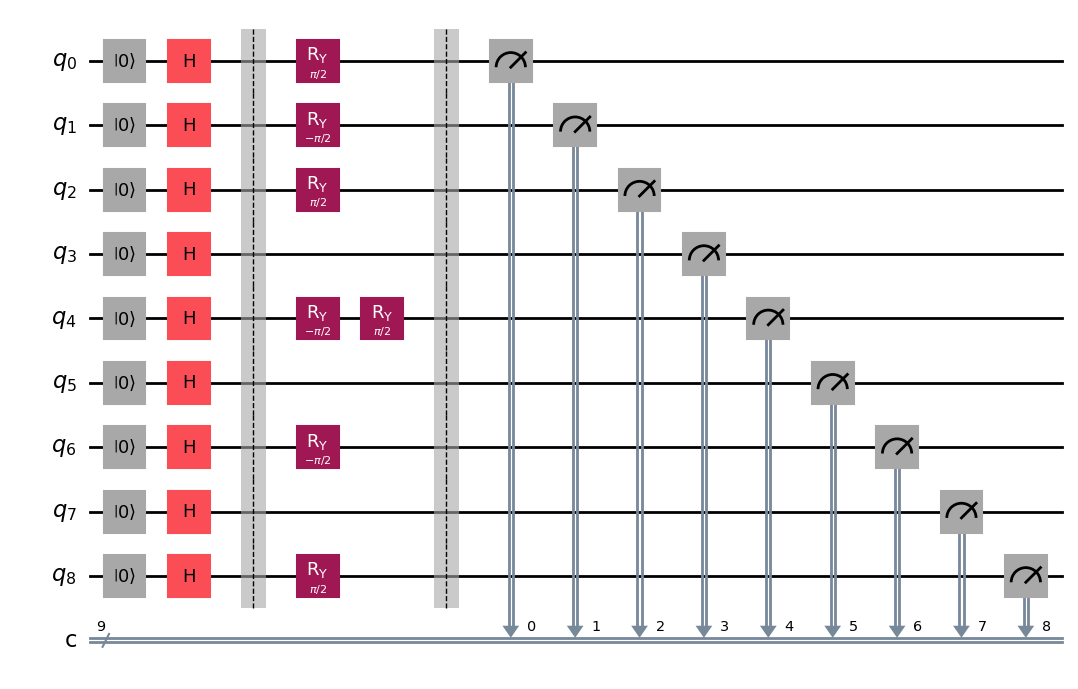

In [ ]:
# O wins
game2 = Game()